# [2주차] [5. ML] 과제
- **과제 목적**: Titanic 데이터 하나로 처음부터 ML의 과정을 끝까지 직접 밟아봅니다. 라이브러리 함수를 호출하는 데서 끝내지 않고, 학습의 핵심(loss, gradient descent)과 평가의 핵심(confusion matrix와 4대 지표)을 **손으로 직접 계산**해 개념을 체화합니다. 이어서 두 모델을 동일 조건에서 비교하고 성능 차이의 원인을 모델 구조 관점에서 해석합니다. 마지막 심화에서는 수업에서 그림으로만 본 overfitting을 실험으로 직접 재현합니다.

> ⚠️ **주의**: LLM를 써도 좋지만, **판단·검증·해석은 반드시 직접** 수행하고 사용 내역을 `## 3`에 기록하세요.


## 0. 환경 설정

In [5]:
!pip install seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 경고문 방지
import warnings ; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

MY_SEED = 1214  # TODO: my birthday
np.random.seed(MY_SEED)

#  Titanic 데이터를 사용
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. 필수 과제

### 1-1. ML 문제 정의 (수업 §2)

코드를 짜기 전에, 이 문제를 ML 문제로 **정식화**합니다. 아래 빈칸을 채우세요.

- 우리는 이 데이터셋에서 타이타닉 탑승자의 생존 여부를 맞춰야합니다. **target(label)**은 어떤 column인가? → `survived`
- 이 데이터에는 label이 (있다). 따라서 학습 방식은 `지도`학습이다.
- target이 (범주형) 이므로, 이 문제는 (분류) 문제다. → 정답: `분류`
- 학습 전에 데이터를 train/test로 나누는 이유를 **본인의 언어로** 한 문장: `모델의 overfitting을 막고 모델 자체의 generalization 성능을 높이기 위해 train/test split을 진행한다. 또한 비지도학습의 경우에도 PCA와 같이 모델이 고차원 데이터를 잘 근사했는가를 평가해야하는 경우에도 해당 train/test split을 사용하기도 한다. 요약해서 설명하자면 공정한 평가와 범용성 있는 모델을 만들기 위해 데이터를 분리해서 사용한다.`


### 1-2. 전처리와 데이터 분할

아래 TODO를 채우고, **각 주석의 빈칸에 '왜 이 단계가 필요한지'를 직접 적으세요.


In [7]:
# 사용할 feature와 target 선택
features = ["pclass", "sex", "age", "fare"]
target = "survived"

df = titanic[features + [target]].copy()

# [빈칸] age의 결측치를 중앙값으로 채우는 이유 (평균이 아니라 중앙값을 쓰는 이유 포함): EDA를 하는 task가 없어서 명확히는 모르겠지만 추론해보자면
# 데이터가 skewed되어있어 robust한 지표로 imputation을 하기 위함이 아닐까한다. 저는 scaler을 쓸 때도 대부분 RobustScaler로 median으로 대체해서 
# 하고는 했다. 결측치 채울 때는 median이 안정적이지만 연산량 때문(이거 말고도 최적화관점에서 말하자면 길다)에 mean을 선호하는 경우도 있는 걸로 알고 있다.
df["age"] = df["age"].fillna(df["age"].median())

# [빈칸] sex를 0/1 숫자로 바꾸는 이유 (모델 입장에서 설명): 컴퓨터는 범주형 데이터를 저렇게 one-hot encoding 혹은 embedding을 하지 않으면 알아먹을 수가 없다.
df["sex"] = (df["sex"] == "female").astype(int)

df = df.dropna()

X = df[features]
y = df[target]

# TODO: train/test를 8:2로 분할하세요. random_state=MY_SEED 사용
# [빈칸] stratify=y 옵션을 주는 이유: median으로 결측치를 채운 것으로 보아 해당 데이터는 클래스간 불균형이 심한 것으로 보인다. 따라서 stratify를 통해
# 두 범주간의 비율을 유지한채 split을 하지 않으면 train 혹은 test에 범주가 쏠려버리는 현상이 일어날 수 있어 그런 것으로 예상된다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= MY_SEED,
    stratify= y
)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train 생존율: {y_train.mean():.3f}, test 생존율: {y_test.mean():.3f}")

train: (712, 4), test: (179, 4)
train 생존율: 0.383, test 생존율: 0.385


### 1-3. Gradient Descent 손계산 (수업 §3)

수업에서 "학습 = loss를 낮추는 방향으로 파라미터를 조금씩 갱신"이라고 했습니다. 이걸 **가장 작은 예제로 직접 계산**합니다.

**설정**: 데이터 3개 $(x, y) = (1,2), (2,4), (3,6)$, 모델 $\hat{y} = wx$ (절편 없음), loss는 MSE

$$L(w) = \frac{1}{3}\sum_{i=1}^{3}(y_i - wx_i)^2, \qquad \frac{\partial L}{\partial w} = -\frac{2}{3}\sum_{i=1}^{3} x_i(y_i - wx_i)$$

**문제**: $w_0 = 0$, learning rate $\eta = 0.1$에서 시작하여 **gradient descent를 3회 반복해 직접 계산**하고, **각 단계에서 $w$가 왜 그 방향으로, 왜 그만큼 움직였는지** 설명하세요. (계산기는 써도 되지만 코드로 먼저 답을 구하면 안 됩니다 — 아래 검증 셀은 손계산이 끝난 뒤에 실행)

| 반복 | 현재 $w$ | 각 데이터의 오차 $(y_i - wx_i)$ | gradient $\frac{\partial L}{\partial w}$ | 갱신된 $w$ |
|---|---|---|---|---|
| 1 | 0 | 2,4,6 | -18.667 | 1.867 |
| 2 | 1.867 | 0.133,0.266,0.399 | -1.241 | 1.991 |
| 3 | 1.991 | 0.009,0.018,0.027 | -0.084 | 1.999 |

**서술**: 매 반복마다 gradient의 크기가 어떻게 변했고, 그것이 $w$의 이동량과 어떤 관계인가? 이 과정이 언제, 왜 멈추게 될까? → `반복마다 gradient크기의 절댓값이 줄어드는 방향으로 변했고 이게 줄수록 w는 조금씩 이동하는 방향으로 진행된다. 이 과정은 gradient가 0에 가깝게 도달해 local optimum이라는 상황에 도달하게 되면 멈추게 된다.`


In [ ]:
# ===== 손계산 검증용 셀 (표를 다 채운 뒤에 실행하세요) =====
# 주의: 위에서 만든 target y(Series)를 덮어쓰지 않도록 여기서는 gx, gy 라는 별도 변수를 쓴다.
gx = np.array([1, 2, 3])
gy = np.array([2, 4, 6])

w = 0.0
lr = 0.1

for step in range(1, 4):
    # TODO: 위 수식대로 gradient를 코드로 옮기세요
    grad = -2/len(gx)*np.dot(gx,gy-w*gx)   # 힌트: -2/len(gx) * np.sum(...) -> 내적이 더 편해서 내적으로 했습니다.

    # [빈칸] gradient의 '반대 방향'으로 이동하는 이유: gradient는 가장 그 값이 양의 방향으로 크게 변화하는 방향이다. 
    # 우리의 목표는 loss를 minimize하는 것이기 때문에 gradient의 반대 방향으로 이동해서 최대한 줄여줘야한다.
    w = w - lr * grad

    loss = np.mean((gy - w * gx) ** 2)
    print(f"step {step}: grad = {grad:+.4f}, w = {w:.4f}, loss = {loss:.4f}")

# 손계산 결과와 출력이 일치하는지 확인하고, 다르면 어디서 틀렸는지 찾아 적으세요: 소수세저리에서 반올림했기 때문에 이정도 오차는 사소하다.

step 1: grad = -18.6667, w = 1.8667, loss = 0.0830
step 2: grad = -1.2444, w = 1.9911, loss = 0.0004
step 3: grad = -0.0830, w = 1.9994, loss = 0.0000


### 1-4. 두 모델 학습과 비교

수업에서 "모든 알고리즘은 (f의 형태 / loss / 찾는 방법)에 대한 서로 다른 답"이라고 했습니다. 형태가 전혀 다른 두 모델을 **같은 데이터, 같은 조건**에서 학습시켜 비교합니다.

- **모델 A**: Logistic Regression (선형 + sigmoid)
- **모델 B**: Decision Tree (재귀 분할)


In [10]:
# 과정 확인 장치: train과 test 성능을 모두 기록합니다
results = {}

# TODO: 모델 A — LogisticRegression을 학습시키세요 (max_iter=1000)
model_a = LogisticRegression(max_iter = 1000)
model_a.fit(X_train, y_train)

# TODO: 모델 B — DecisionTreeClassifier를 학습시키세요 (random_state=MY_SEED)
model_b = DecisionTreeClassifier(random_state= MY_SEED)
model_b.fit(X_train, y_train)

for name, model in [("Logistic Regression", model_a), ("Decision Tree", model_b)]:
    # [빈칸] train 정확도와 test 정확도를 '둘 다' 기록하는 이유 (수업 §3의 개념과 연결해서): 처음 본 데이터를 잘 맞추는지와 지금 들고 있는 데이터를 잘 맞추
    # 는지를 전부다 보기 위해서 둘 다 기록해두는것 같다. 두가지를 전부 기록함으로써 범용성, 정확성을 전부 평가할 수 있다.
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = (train_acc, test_acc)
    print(f"{name:20s} | train acc: {train_acc:.4f} | test acc: {test_acc:.4f}")

Logistic Regression  | train acc: 0.7851 | test acc: 0.7821
Decision Tree        | train acc: 0.9789 | test acc: 0.7598


### 1-5. 평가지표 직접 유도

수업에서 "Confusion Matrix 하나에서 4개 지표가 전부 유도된다"고 했습니다. **sklearn의 지표 함수를 쓰기 전에**, TP/TN/FP/FN으로부터 직접 계산해 봅니다. (모델 A 기준)


In [15]:
y_pred = model_a.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# sklearn의 confusion_matrix 배치: [[TN, FP], [FN, TP]]
TN, FP = cm[0]
FN, TP = cm[1]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")

# TODO: 아래 4개 지표를 TP/TN/FP/FN '만으로' 직접 계산하세요 (sklearn 함수 사용 금지)
my_accuracy  = (TP + TN) / (TP + TN + FP + FN)
my_precision = TP / (TP + FP)   # [빈칸] precision의 분모에 들어가는 것과 그 의미: TP + FP, 모델이 양성이라고 예측한 전체 건수
my_recall    = TP / (TP + FN)   # [빈칸] recall의 분모에 들어가는 것과 그 의미: TP + FN, 실제 양성인 전체 건수
my_f1        = (2 * TP) / (2 * TP + FP + FN)   # 힌트: precision과 recall의 조화평균

# 검증: sklearn과 비교 (통과하지 못하면 수식을 다시 확인)
assert np.isclose(my_accuracy,  accuracy_score(y_test, y_pred))
assert np.isclose(my_precision, precision_score(y_test, y_pred))
assert np.isclose(my_recall,    recall_score(y_test, y_pred))
assert np.isclose(my_f1,        f1_score(y_test, y_pred))
print("✅ 4개 지표 모두 sklearn과 일치")

print(f"{[float(round(x, 3)) for x in [my_accuracy, my_precision, my_recall, my_f1]]}")

Confusion Matrix:
 [[92 18]
 [21 48]]
TP=48, TN=92, FP=18, FN=21
✅ 4개 지표 모두 sklearn과 일치
[0.782, 0.727, 0.696, 0.711]


seed 10개: [1214, 0, 1, 5, 21, 99, 123, 625, 2026, 4121]

[Logistic Regression]
  train_acc  mean 0.7947 | std 0.0077 | min 0.7851 | max 0.8048 | 흔들린 폭 0.0197
  test_acc   mean 0.7838 | std 0.0134 | min 0.7709 | max 0.8101 | 흔들린 폭 0.0391
  gap        mean 0.0109 | std 0.0169 | min -0.0249 | max 0.0338 | 흔들린 폭 0.0588
  precision  mean 0.7269 | std 0.0207 | min 0.7000 | max 0.7612 | 흔들린 폭 0.0612
  recall     mean 0.7043 | std 0.0299 | min 0.6522 | max 0.7536 | 흔들린 폭 0.1014
  f1         mean 0.7151 | std 0.0193 | min 0.6870 | max 0.7500 | 흔들린 폭 0.0630

[Decision Tree]
  train_acc  mean 0.9813 | std 0.0020 | min 0.9789 | max 0.9846 | 흔들린 폭 0.0056
  test_acc   mean 0.7676 | std 0.0201 | min 0.7263 | max 0.7933 | 흔들린 폭 0.0670
  gap        mean 0.2137 | std 0.0214 | min 0.1856 | max 0.2583 | 흔들린 폭 0.0727
  precision  mean 0.7073 | std 0.0328 | min 0.6351 | max 0.7458 | 흔들린 폭 0.1106
  recall     mean 0.6812 | std 0.0427 | min 0.6087 | max 0.7391 | 흔들린 폭 0.1304
  f1         mean 0.6929 | std 0.0

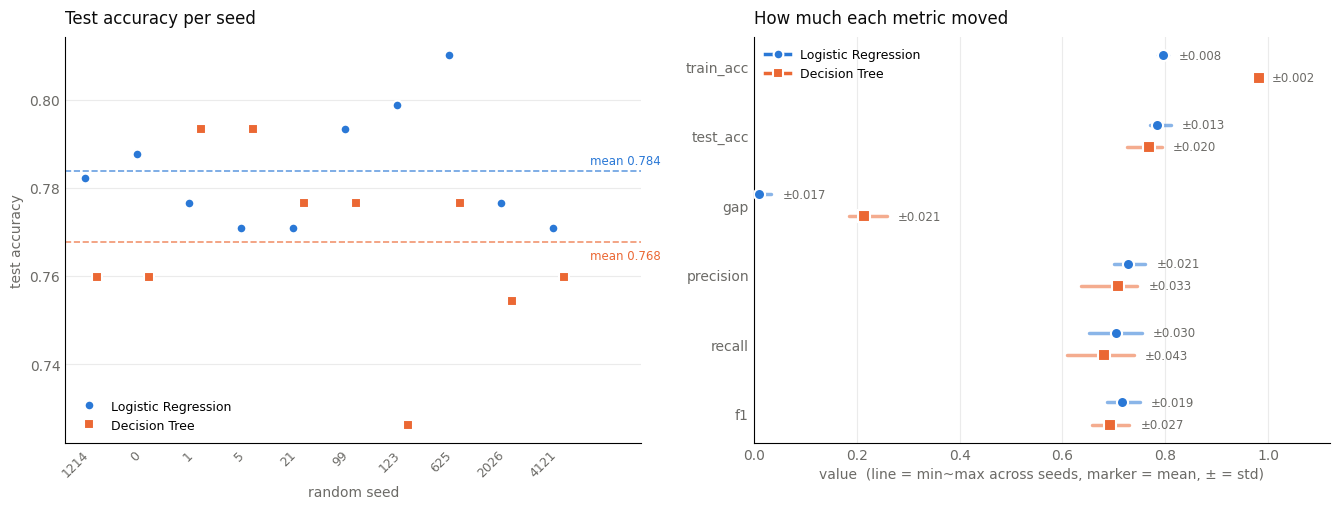

In [20]:
# ===== 1-6 (3)번용: MY_SEED를 바꿔가며 1-2 ~ 1-4를 반복하고, 어떤 수치가 얼마나 흔들리는지 확인 =====
SEEDS = [MY_SEED, 0, 1, 5, 21, 99, 123, 625, 2026, 4121]
METRICS = ["train_acc", "test_acc", "gap", "precision", "recall", "f1"]
MODELS = ["Logistic Regression", "Decision Tree"]
COLOR = {"Logistic Regression": "#2a78d6", "Decision Tree": "#eb6834"}  # 색은 '모델'에 고정 배정


def run_once(seed):
    """1-2(전처리·분할) → 1-4(두 모델 학습) → 지표 계산을 seed 하나로 한 번 수행"""
    # --- 1-2 재현: 전처리 자체는 seed와 무관하지만, 원 코드를 그대로 다시 밟는다 ---
    d = titanic[features + [target]].copy()
    d["age"] = d["age"].fillna(d["age"].median())
    d["sex"] = (d["sex"] == "female").astype(int)
    d = d.dropna()
    Xs, ys = d[features], d[target]
    Xtr, Xte, ytr, yte = train_test_split(
        Xs, ys, test_size=0.2, random_state=seed, stratify=ys
    )
    # --- 1-4 재현: 같은 데이터, 같은 조건에서 두 모델 학습 ---
    fitted = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=seed),
    }
    rows = []
    for name, m in fitted.items():
        m.fit(Xtr, ytr)
        pred = m.predict(Xte)
        tr = accuracy_score(ytr, m.predict(Xtr))
        te = accuracy_score(yte, pred)
        rows.append({
            "seed": seed, "model": name,
            "train_acc": tr, "test_acc": te, "gap": tr - te,   # gap = train - test (과적합 폭)
            "precision": precision_score(yte, pred),
            "recall": recall_score(yte, pred),
            "f1": f1_score(yte, pred),
        })
    return rows


runs = pd.DataFrame([r for s in SEEDS for r in run_once(s)])

# ---------- 요약: 평균 ± 표준편차, 그리고 흔들린 폭(max - min) ----------
print(f"seed {len(SEEDS)}개: {SEEDS}\n")
for m in MODELS:
    sub = runs[runs["model"] == m]
    print(f"[{m}]")
    for k in METRICS:
        v = sub[k]
        print(f"  {k:10s} mean {v.mean():.4f} | std {v.std():.4f} "
              f"| min {v.min():.4f} | max {v.max():.4f} | 흔들린 폭 {v.max() - v.min():.4f}")
    print()

widest = max(
    ((m, k, runs.loc[runs["model"] == m, k].max() - runs.loc[runs["model"] == m, k].min())
     for m in MODELS for k in METRICS), key=lambda t: t[2]
)
print(f"→ 가장 크게 흔들린 수치: {widest[0]}의 {widest[1]} (폭 {widest[2]:.4f})")

# ---------- 그래프 ----------
INK, MUTED = "#0b0b0b", "#6b6a66"
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# (좌) seed별 test accuracy — 흔들림의 원본. seed는 순서 없는 범주이므로 선으로 잇지 않는다
ax = axes[0]
x = np.arange(len(SEEDS))
MARKER = {"Logistic Regression": "o", "Decision Tree": "s"}  # 색만이 아니라 모양으로도 구분
for j, m in enumerate(MODELS):
    sub = runs[runs["model"] == m].set_index("seed").loc[SEEDS]
    ax.plot(x + (j - 0.5) * 0.22, sub["test_acc"], MARKER[m], ms=7, color=COLOR[m],
            mec="white", mew=1.5, label=m, zorder=3)
    ax.axhline(sub["test_acc"].mean(), color=COLOR[m], lw=1.2, ls="--", alpha=0.7, zorder=1)
    ax.annotate(f"mean {sub['test_acc'].mean():.3f}",
                (len(SEEDS) - 0.5, sub["test_acc"].mean()),
                xytext=(4, 5 if j == 0 else -12), textcoords="offset points",
                fontsize=8.5, color=COLOR[m])
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in SEEDS], rotation=45, ha="right", fontsize=9)
ax.set_xlabel("random seed", fontsize=10, color=MUTED)
ax.set_ylabel("test accuracy", fontsize=10, color=MUTED)
ax.set_title("Test accuracy per seed", fontsize=12, color=INK, loc="left", pad=10)
ax.set_xlim(-0.5, len(SEEDS) + 0.6)
ax.grid(axis="y", alpha=0.25, lw=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, loc="lower left", numpoints=1)

# (우) 지표별 흔들린 폭 — min~max 구간선 + 평균 마커
ax = axes[1]
for i, k in enumerate(METRICS):
    for j, m in enumerate(MODELS):
        v = runs.loc[runs["model"] == m, k]
        yy = i + (j - 0.5) * 0.32
        ax.plot([v.min(), v.max()], [yy, yy], lw=2.5, color=COLOR[m],
                solid_capstyle="round", alpha=0.55, zorder=2)
        ax.plot(v.mean(), yy, MARKER[m], ms=8, color=COLOR[m], mec="white", mew=1.5, zorder=3)
        ax.annotate(f"±{v.std():.3f}", (v.max(), yy), xytext=(8, 0),
                    textcoords="offset points", va="center", fontsize=8.5, color=MUTED)
ax.set_yticks(range(len(METRICS)))
ax.set_yticklabels(METRICS, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 1.12)
ax.set_xlabel("value  (line = min~max across seeds, marker = mean, ± = std)",
              fontsize=10, color=MUTED)
ax.set_title("How much each metric moved", fontsize=12, color=INK, loc="left", pad=10)
ax.grid(axis="x", alpha=0.25, lw=0.8)
ax.set_axisbelow(True)
ax.legend(handles=[plt.Line2D([], [], color=COLOR[m], lw=2.5, marker=MARKER[m], ms=7,
                              mec="white", mew=1.5, label=m) for m in MODELS],
          frameon=False, fontsize=9, loc="upper left")

for a in axes:
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.tick_params(colors=MUTED, length=0)

plt.tight_layout()
plt.show()


### 1-6. 결과 해석 (필수 서술)

아래 4개 질문에 **본인의 실험 결과 수치를 근거로** 답하세요. (수치 없이 일반론만 쓰면 감점)

1. **왜 이러한 결과가 나왔는가?** — 두 모델의 test 정확도는 각각 얼마였고, 이 데이터에서 그 정도 성능이 나온 이유를 feature 관점에서 추측하면? → `test 정확도는 a에서 0.7821였고 b에서 0.7589이었다. 데이터의 실제 경계가 0/1로 단순하기 때문에 단순한 가설공간을 띄고 있는 logistic regression이 tree에 비해 성능이 뛰어나다. `
2. **두 모델의 성능 차이는 어디에서 발생했는가?** — train acc와 test acc의 '차이'가 두 모델에서 어떻게 달랐는가? 이를 모델 구조(선형 경계 vs 재귀 분할)의 관점에서 해석하면? → `decision tree기반의 모델에서 test acc의 값이 급감하는 것을 알 수 있었다. Decision tree는 depth를 지정해주지 않으면 과도하게 공간을 재귀적으로 분할하게 되어 과적합이 일어나기 쉬운 모델이다. 따라서 지엽적인 특성까지 전부 암기해버려 범용적인 성능이 나오지 못하는 반면에 regression모델은 선형 경계를 나누기 때문에 과적합이 일어날 가능성이 적어 test_acc는 덜 감소하는 것을 알 수 있었다.`
3. **실험 조건을 변경하면 결과가 어떻게 달라지는가?** — `MY_SEED`를 다른 값으로 바꿔 1-2 ~ 1-4를 다시 실행해 보고, 어떤 수치가 얼마나 흔들렸는지 기록. 이 흔들림을 줄이는 방법으로 수업에서 배운 것은? → `decision tree의 recall이 0.1304로 가장 많이 흔들렸다. 이 흔들림은 depth를 조절해 조기에 종료되도록 하는 방향으로 수업에서 흔들림을 줄일 수 있다고 배웠다. 혹은 저와 같은 경우엔 그냥 week learner를 여러개 이어붙이는 tree기반의 boosting알고리즘을 사용하는 방식으로 이 문제를 해결하곤 한다.`
4. **예상과 다른 결과가 나왔다면 그 원인은 무엇인가?** — 과제를 시작하기 전 예상과 달랐던 지점 하나와, 그 원인에 대한 본인의 가설: → `Decision tree에서 이렇게 train, test accuracy가 차이가 클지 예상하지 못했다. 그 원인은 당연히 depth를 조절하지 않은데에 있으며 또한 simple classification이니 logistic regression이 범용성 측면에서 압도한 것으로 보인다.`


## 2. 심화 과제 (선택) -> 바로 해버립니다.

### 2-1. Overfitting 직접 재현하기

 overfitting/underfitting curve를 **본인 데이터로 직접 그립니다.** Decision Tree의 `max_depth`를 1부터 15까지 바꿔가며 train/test 정확도를 기록하세요.


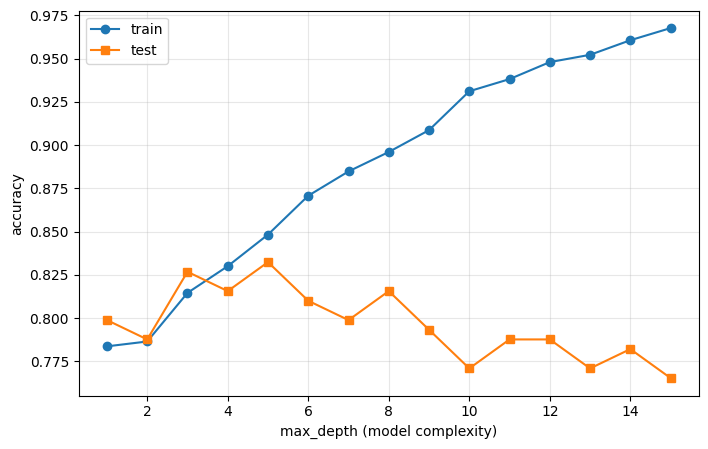

In [22]:
depths = range(1, 16)
train_scores, test_scores = [], []

for d in depths:
    # TODO: max_depth=d인 DecisionTreeClassifier를 학습시키고
    #       train/test 정확도를 각 리스트에 추가하세요
    tree = DecisionTreeClassifier(max_depth = d, random_state=MY_SEED)
    tree.fit(X_train,y_train)
    train_acc_2 = accuracy_score(y_train, tree.predict(X_train))
    test_acc_2 = accuracy_score(y_test, tree.predict(X_test))
    train_scores.append(train_acc_2) ; test_scores.append(test_acc_2)

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker="o", label="train")
plt.plot(depths, test_scores, marker="s", label="test")
# Colab 기본 환경(vs code로 하는걸 강추)엔 한글 폰트가 없어 제목/라벨은 영문으로 둔다(한글이면 □로 깨짐)
# -> font 지정해주면 됩니다 plt.rcParams['font.family'] = 'malgun gothic'
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 해석 (필수):
# - 그래프에서 underfitting 구간과 overfitting 구간은 각각 어디인가? → 
# ~5까지가 underfitting, 이후부터 overfitting 구간이라고 생각한다. 
# - 본인 데이터 기준 최적의 max_depth와 그렇게 판단한 근거는? → 
# 최적의 max_depth는 5라고 생각한다. test_accuracy는 overfitting이 일어나기 전의 underfitting
# 구간에서는 증가하다가 overfitting이 일어나며 감소하기 시작하는데 가장 최대값을 띄고 있는 5가 최적이다.
# - 이 그래프가 수업의 "train loss만 낮추는 건 쉽다"는 문장과 어떻게 연결되는가? → 
# 깊이가 깊어질수록 선형적으로 증가하는 것을 알 수 있는데 이를 통해 train loss는 그냥 과적합을 내면 되기 때문에 
# 낮추기 쉽다고 언급했던 것 같습니다. (그래프 상에서 단조증가함을 확인)

### 2-2. 비지도학습 미리보기 — label을 가리면 무엇이 보일까?

지금까지는 `survived`라는 label을 알고 학습했습니다(지도학습). 이번엔 **label을 일부러 가리고**, 데이터의 구조만으로 무엇이 보이는지 확인합니다.


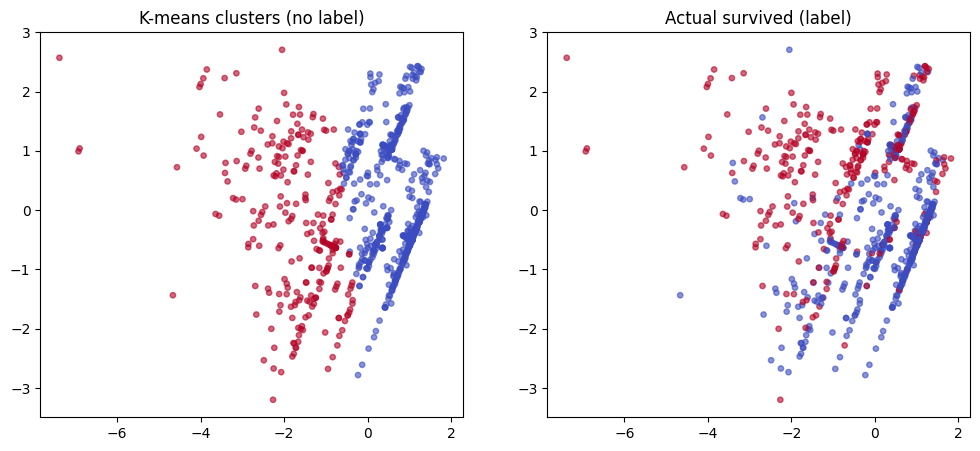

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# [빈칸] PCA/K-means 전에 스케일링이 필요한 이유 (fare와 age의 단위를 생각해 보세요): 
# fare은 요금이라 달러 단위로 붙을 것이고 age는 나이라 ~세 단위로 붙을 건데 나이는 많아봤자 100살이지만
# 요금은 천차만별이기 때문에 스케일링을 통해 맞춰줘야합니다.
X_scaled = StandardScaler().fit_transform(X)

# TODO: PCA로 2차원으로 축소하세요
X_2d = PCA(n_components= 2).fit_transform(X_scaled)

# TODO: K-means로 2개 군집을 찾으세요 (random_state=MY_SEED, n_init=10)
clusters = KMeans(n_clusters=2, random_state=MY_SEED, n_init=10).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="coolwarm", alpha=0.6, s=15)
axes[0].set_title("K-means clusters (no label)")
# ⚠️ c=y 로 넘기면 pandas Series를 단일 RGBA로 오해해 ValueError가 난다. 반드시 c=y.values
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y.values, cmap="coolwarm", alpha=0.6, s=15)
axes[1].set_title("Actual survived (label)")
plt.show()

# 해석 (필수):
# - K-means가 찾은 군집은 실제 생존 여부와 얼마나 겹치는가? → 
# 얼마나? 수치적인 정답을 내리지는 못하겠지만 중간 부분은 겹치지 않지만 일부 가장 자리 영역은 대체로 겹치는 것을 알 수 있다.
# - 겹친다면/겹치지 않는다면, 그 이유는 무엇이라고 생각하는가?
#   (힌트: K-means는 무엇을 기준으로 데이터를 나누는가?) → 
# K-means는 거리기반으로 데이터를 나누는데 standardscaler를 적용하게 되면 어떤 feature를
# 더 중요하게 봐야할지를 모델이 구분하지 못하게 되고 뭉개버린다. 따라서 이를 해결하기 위해서는 범주형, 연속형마다
# 동일하게 유클리디안 거리로 재는것이 아니라 거리 지표를 다른 것으로 바꾸거나 지도학습을 진행하는 방식으로 해결해줘야한다. 

## 3. 생성형AI 활용 방법

문제를 풀면서 GPT, Claude 등 생성형 AI를 **어디에, 어떻게** 썼는지 기록하는 곳입니다. (사용하지 않았다면 "사용하지 않음"이라고 적으세요)

- **활용 방법**: 어떤 문제에서, 어떤 목적으로(개념 질문 / 에러 해결 / 코드 초안 등) 사용했는지 → `위의 변동성을 파악하는 문제에서 그래프로 좀 직관적으로 보고 싶어 셀에 그래프 그려주는 코드 짜달라고 부탁했습니다.`
- **AI 답변 중 그대로 쓰지 않고 직접 수정·검증한 부분**: → `그거외에는 안 썼습니다.`
- **대화 내역 붙여넣기**: (아래에 전체 대화를 붙여넣으세요)

```
1-6번 cell위에 MY_SEED값을 바꾸면서 1-2~1-4를 수행하고 어떤 수치가 얼마나 흔들렸는지를 확인하기 위해 그래프를 그리려고 하는데 이것을 해주는 코드를 셀 하나에 짜줘바
```


## 4. 회고

- **가장 어려웠던 부분**과 그것을 어떻게 해결했는지 (또는 아직 해결하지 못했는지, 없다면 없음이라고 적어도 됨): → `특별히 없었습니다.`
- 이번 과제 내용 중 기술블로그 '과제 복습' 섹션에 정리할 핵심 1가지: → `늘 그래왔든 이번주는 특히 더 시간을 많이 써서 모든 내용에 대한 깊이 있는 정리를 수행하려한다.(관심분야이기도 하고 일부 까먹은 내용도 있어서 공부에 더 시간을 쓰려합니다.)`
